In [165]:
from langchain_ollama import ChatOllama
from typing import TypedDict
from langgraph.graph import state,START,END

In [166]:
class State(TypedDict):
    query:str
    result:str

In [167]:
def greeting(state:State):
    return {
        "result":"Hi! Buddy How are you!"
    }

In [ ]:
def math_node(state:State):
    query=state["query"]
    try:
        answer=eval(query)
        return {
            "result":f"answer={answer}"
        }
    except:
        return {"result":"Invalid expression"}

In [ ]:
def general_node(state:State):
    return {
        "result":"This is the general node."
    }

In [ ]:
def router(state):
    query = state["query"].lower().strip()

    print("Query:", query)

    greetings = ["hi", "hello", "hey"]

    if query in greetings:
        print("Routing to Greeting")
        return "greeting"

    math_symbols = ["+", "-", "*", "/"]

    if any(symbol in query for symbol in math_symbols):
        print("Routing to Math")
        return "math"

    print("Routing to General")
    return "general"

In [ ]:
from langgraph.graph import StateGraph,START,END

In [ ]:
builder=StateGraph(State)

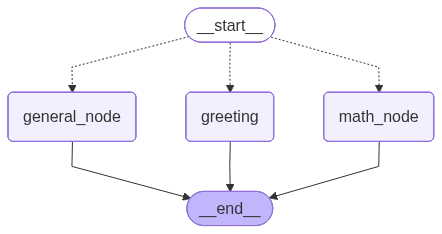

In [ ]:
builder.add_node("greeting",greeting)
builder.add_node("math_node",math_node)
builder.add_node("general_node",general_node)

builder.add_conditional_edges(
    START,
    router,{
        "greeting":"greeting",
        "math_node":"math_node",
        "general_node":"general_node"
    }
)

builder.add_edge("greeting",END)
builder.add_edge("math_node",END)
builder.add_edge("general_node",END)

graph=builder.compile()
graph



In [ ]:
graph.invoke({'query':"Hey"})

Query: hey
Routing to Greeting


{'query': 'Hey', 'result': 'Hi! Buddy How are you!'}